## Anisotropic Diffusion Filtering for MRI Image Denoising

This notebook implements anisotropic diffusion filtering for MRI image denoising using PDE-based numerical methods. Both steady-state and time-dependent formulations are investigated using finite difference, finite volume, nonlinear iteration, and time integration methods for linear and nonlinear diffusion models.

The denoising problem is studied both through the stationary diffusion-reaction equation and through time integration of the transient PDE.

The diffusion-reaction equation considered is

$$
\begin{aligned}
\frac{\partial \phi}{\partial t}
&=
\nabla \cdot (c \nabla \phi)
+
\lambda (\phi_0-\phi),
\quad \text{in } \Omega,
\\
\phi(x,y,0)
&=
\phi_0(x,y),
\quad \text{in } \Omega,
\\
c \frac{\partial \phi}{\partial \mathbf{n}}
&=
0,
\quad \text{on } \partial \Omega.
\end{aligned}
$$

Here, $\phi$ represents the filtered image and $\phi_0$ the original image, $t$ denotes time, $\lambda \geq 0$ is the fidelity parameter controlling confidence in the original image, and $c>0$ is the diffusion coefficient, defined either as

$$
c = 1
$$

or

$$
c(\|\nabla \phi\|)=
\frac{1}{1+\left(\frac{\|\nabla\phi\|}{K}\right)^2}.
$$

The nonlinear diffusion coefficient reduces smoothing near sharp gradients, allowing edges in the image to be preserved while noise is removed in smoother regions.

The computational domain is given by $(x,y)\in\Omega=(0,1)^2$ and discretized using a uniform grid with mesh size

$$
h=\frac{1}{N}.
$$

A vertex-centered approach is used for the finite difference method, while a cell-centered approach is employed for the finite volume discretization.

Explicit Euler and Implicit Euler time integration schemes are implemented using timestep

$$
\Delta t = 10^{-5}.
$$

The nonlinear diffusion coefficient is treated using a Picard iteration for the steady-state problem. The iteration is terminated after at most 100 iterations or once

$$
\frac{\|\mathbf{u}_{k+1}-\mathbf{u}_k\|}{\sqrt{N}}
<
10^{-5}.
$$

For the experiments, we use $N=64$ and $K=5$.

## Running the Experiments

Run all cells sequentially to reproduce the denoising experiments, figures, and time integration results.

Before running the notebook, ensure that the file `SL_simulated.gif` is located in the same directory as the notebook, since it is used as input for the MRI denoising experiments.

### Importing the relevant libraries

In [52]:
import numpy as np
from typing import Callable
from PIL import Image
import scipy
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import copy

### Defining the images with and without noise

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

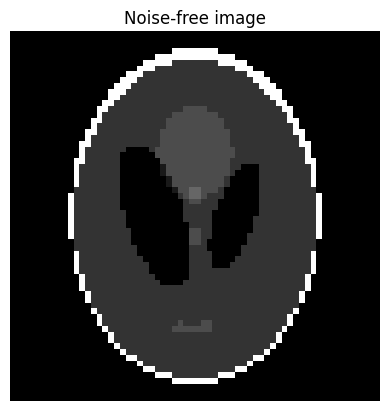

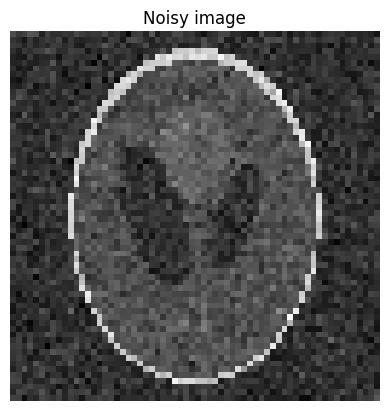

In [53]:
gif_name = 'SL_simulated.gif'

Im = Image.open(gif_name)

fm = np.array([])
fn = np.array(Im)/255.0
nx, ny = fn.shape

if gif_name == 'SL_simulated.gif':
    fm = fn
    sigma = 0.1
    np.random.seed(0)
    fn = fm + sigma * np.random.randn(nx, ny)
    # Plot the model image
    plt.figure()
    plt.title('Noise-free image')
    plt.imshow(fm, extent=[0, 1, 0, 1], cmap = 'gray')
    plt.axis('square')
    plt.axis('off')

# Plot the noisy image
plt.figure()
plt.title('Noisy image')
plt.imshow(fn, extent=[0, 1, 0, 1], cmap = 'gray')
plt.axis('square')
plt.axis('off')

##### Building the A matrix for FDM

In [54]:
def build_A_matrix_FDM(N_x: int, N_y: int, dx: float, dy: float, Lambda: float, c: Callable,
                        u: np.ndarray = 0, nonlinear: bool = False) -> lil_matrix:
    """
    Builds the discretized matrix A for the diffusion-reaction equation using a vertex centered approach and FDM.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.
        Lambda (float): Fidelity parameter. It is greater or equal to 0.
        c (Callable): Diffusion coefficient which is a function in space which can also depend on phi and t. It is greater than 0.
        u (np.ndarray): Estimated value of phi. This is used for iteration. It is set to 0 for default.
        nonlinear (bool): Indicates whether we want to use the nonlinear c or the constant c. Standard value False.
        
    Returns:
        A (lil_matrix): Discretized matrix A.
    """
    N = N_x * N_y

    #We use lil_matrix since we have a sparse matrix. This helps solving the system faster
    A = lil_matrix((N, N))

    for j in range(N_y):
        for i in range(N_x):
            n = i + j * N_x

            #Defining c with the 1/2 values
            ci_postive = (c(x = i*dx,y = j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = (i+1)*dx,y = j*dy,u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2
            ci_negative = (c(x = i*dx, y = j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = (i-1)*dx,y = j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2
            cj_postive = (c(x = i*dx,y = j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = i*dx,y = (j+1)*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2
            cj_negative = (c(x = i*dx, y = j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = i*dx, y = (j-1)*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2


            #Creating the coefficients
            #Here C represents (i,j), N represents (i,j+1), E represents (i+1,j), S represents (i,j-1) and W represents (i-1,j)
            a_C = - ci_postive*1/(dx)**2 - ci_negative*1/(dx)**2 - cj_postive*1/(dy)**2 - cj_negative*1/(dy)**2 - Lambda*1
            a_N = cj_postive*1/(dy)**2
            a_E = ci_postive*1/(dx)**2
            a_S = cj_negative*1/(dy)**2
            a_W = ci_negative*1/(dx)**2


            #For the boundary conditions we will devide everything by 2 except for the term where it doubles
            #Now if we hit a corner point, everything will be devided by 2 and the center point will be divided by 4

            # Adjustments for x boundaries.
            if i == 0 and j != 0 and j != N_y - 1:
                a_N /= 2
                a_S /= 2
                a_C = (a_C + ci_negative*1/(dx)**2 - ci_postive*1/(dx)**2)/2
        
            if i == N_x - 1 and j != 0 and j != N_y - 1:
                a_N /= 2
                a_C = (a_C - ci_negative*1/(dx)**2 + ci_postive*1/(dx)**2)/2
                a_S /= 2

            # Adjustments for y boundaries
            if j == 0 and i != 0 and i != N_x - 1:
                a_E /= 2
                a_C = (a_C + cj_negative*1/(dy)**2 - cj_postive*1/(dy)**2)/2
                a_W /= 2

            if j == N_y - 1 and i != 0 and i != N_x - 1:
                a_E /= 2
                a_C = (a_C - cj_negative*1/(dy)**2 + cj_postive*1/(dy)**2)/2
                a_W /= 2
            
            # Adjustments for the cornerpoints
            if i == 0 and j == 0:
                a_N /= 2
                a_S /= 2
                a_W /= 2
                a_E /= 2
                a_C = (a_C + ci_negative*1/(dx)**2 - ci_postive*1/(dx)**2 + cj_negative*1/(dy)**2 - cj_postive*1/(dy)**2)/4

            if i == 0 and j == N_y-1:
                a_N /= 2
                a_S /= 2
                a_W /= 2
                a_E /= 2
                a_C = (a_C + ci_negative*1/(dx)**2 - ci_postive*1/(dx)**2 - cj_negative*1/(dy)**2 + cj_postive*1/(dy)**2)/4

            if i == N_x-1 and j == 0:
                a_N /= 2
                a_S /= 2
                a_W /= 2
                a_E /= 2
                a_C = (a_C - ci_negative*1/(dx)**2 + ci_postive*1/(dx)**2 + cj_negative*1/(dy)**2 - cj_postive*1/(dy)**2)/4

            if i == N_x-1 and j == N_y-1:
                a_N /= 2
                a_S /= 2
                a_W /= 2
                a_E /= 2
                a_C = (a_C - ci_negative*1/(dx)**2 + ci_postive*1/(dx)**2 - cj_negative*1/(dy)**2 + cj_postive*1/(dy)**2)/4


            # Assembling the matrix
            A[n, n] = a_C
            if i < N_x - 1:
                A[n, i + 1 + j * N_x] = a_E  # East neighbor (i+1, j)
            if i > 0:
                A[n, i - 1 + j * N_x] = a_W  # West neighbor (i-1, j)
            if j < N_y - 1:
                A[n, i + (j + 1) * N_y] = a_N  # North neighbor (i, j+1)
            if j > 0:
                A[n, i + (j - 1) * N_y] = a_S  # South neighbor (i, j-1)

    return A

##### Building the f vector for FDM

In [55]:
def build_f_vector_FDM(N_x: int, N_y: int, Lambda: float, phi0: np.ndarray) -> np.ndarray:
    """
    Builds the right hand side vector f for the discretized reaction-diffusion equation using a vertex centered approach and FDM.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        Lambda (float): Fidelity parameter. It is greater or equal to 0.
        phi0 (np.ndarray): Initial image in x and y.

    Returns:
        f (np.ndarray): right hand side vector f.
    """
    N = N_x * N_y
    f = np.zeros(N)
    for j in range(N_y):
        for i in range(N_x):
            n = i + j * N_x
            f[n] = -Lambda*float(phi0[-1-j,i]) #We need to revert it since we are getting the values from the last row until the first row

            #We also need to account for the boundary points where we devide by 2
            if i == 0 or i == N_x-1:
                f[n] /= 2
            
            if j == 0 or j == N_y-1:
                f[n] /= 2

    return f

#### Creating the diffusion coefficient c

In [56]:
#Defining the parameters
def c(x: float = 0,y: float = 0, t: float = 0, u: np.ndarray = 0,
    N_x: int = 0, N_y: int = 0, dx: float = 0, dy: float = 0, K: float = 5, nonlinear: bool = False) -> float:
    """
    The diffusion coefficient. Either constant or dependent on phi.

    Parameters:
        x (float): x value. Standard value is 0.
        y (float): y value. Standard value is 0.
        t (float): t value. Standard value is 0.
        u (np.ndarray): array of all phi values of the previous iteration. Standard value 0.
        N_x (int): Number of grid points in the x direction. Standard value is 0.
        N_y (int): Number of grid points in the y direction. Standard value is 0.
        dx (float): Grid spacing in the x direction. Standard value is 0.
        dy (float): Grid spacing in the y direction. Standard value is 0.
        K (float): coefficient for nonlinear c. Standard value is 5.
        nonlinear (bool): Indicates whether we want to use the nonlinear c or the constant c. Standard value False.

    Returns:
        c (float): value evaluated in x, y, t and u.
    """

    #Here we check if we are computing the constant c or the nonlinear c
    if nonlinear == False:
        return 1
    
    #Here we check which u phi value we should take in order to approximate the non linear term
    i = int(x // dx)
    j = int(y // dy)

    #Checking on which center point we are right now for phi
    n = i + j * N_x

    #We do not want our c index to go out of bounds. As this c value should not even be computed in the first place
    if i == -1 or i == N_x or j == -1 or j == N_y:
        return 0

    #We apply the boundary conditions
    if i == 0 or i == N_x - 1:
        pdv_x = 0
    else:
        pdv_x = (u[n+1]-u[n-1])/(2*dx)
    
    if j == 0 or j == N_y - 1:
        pdv_y = 0
    else:
        pdv_y = (u[n+N_x]-u[n-N_x])/(2*dy)

    #computing c
    gradient = np.sqrt(pdv_x**2+pdv_y**2)
    c = 1/(1+(gradient/K)**2)

    return c

##### Solving the equation for multiple lambdas for FDM with constant c

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\3935519222.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'$\lambda$ = {fidelity}')
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\3935519222.py:33: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$')


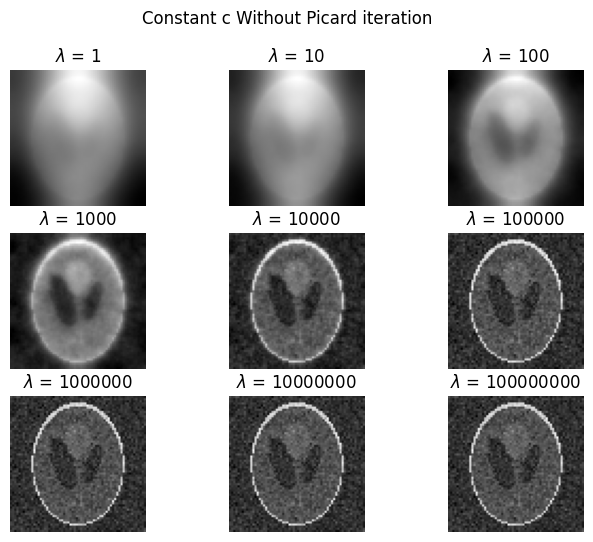

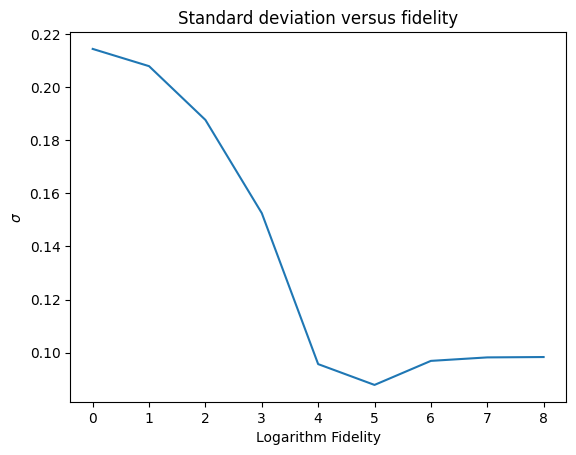

In [57]:
#Defining the parameters
N_x = 64
N_y = 64
dx = 1/63
dy = 1/63

method = 0
plt.figure(figsize=(8,6))
plt.suptitle('Constant c Without Picard iteration')
sigma = np.zeros(9)
for i in range(9):
    fidelity = 10**(i)
    A = build_A_matrix_FDM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = fidelity, c = c)
    b = build_f_vector_FDM(N_x = N_x, N_y = N_y, Lambda = fidelity, phi0 = fn)
    u = spsolve(A.tocsr(),b)
    #We need to reshape it back to 64x64
    fs = u.reshape((64,64))[::-1]

    plt.subplot(3, 3, i+1)
    plt.title(f'$\lambda$ = {fidelity}')
    plt.imshow(fs, extent=[0, 1, 0, 1], cmap = 'gray')
    plt.axis('square')
    plt.axis('off')

    if fm.size > 0:
        sigma[i] = np.linalg.norm(fs - fm, ord='fro') / np.sqrt(N_x*N_y)

if fm.size > 0:
    plt.figure()
    plt.title('Standard deviation versus fidelity')
    plt.plot(range(9), sigma)
    plt.xlabel('Logarithm Fidelity')
    plt.ylabel('$\sigma$')

#### Building the A matrix for FVM

In [58]:
def build_A_matrix_FVM(N_x: int, N_y: int, dx: float, dy: float, Lambda: float, c: Callable,
                       u: np.ndarray = 0, nonlinear: bool = False) -> lil_matrix:
    """
    Builds the discretized matrix A for the diffusion-reaction equation using a cell centered approach using FVM.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.
        Lambda (float): Fidelity parameter. It is greater or equal to 0.
        c (Callable): Diffusion coefficient which is a function in space which can also depend on phi and t. It is greater than 0.
        u (np.ndarray): Estimated value of phi. This is used for iteration. It is set to 0 for default.
        nonlinear (bool): Indicates whether we want to use the nonlinear c or the constant c. Standard value False.

    Returns:
        A (lil_matrix): Discretized matrix A.
    """
    N = N_x * N_y
    #We use lil_matrix since we have a sparse matrix. This helps solving the system faster
    A = lil_matrix((N, N))

    for j in range(N_y):
        for i in range(N_x):
            n = i + j * N_x

            #Defining c with the 1/2 values
            #We are using a cell centered approach, so the value starts at dx/2 and dy/2
            ci_postive = (c(x = dx/2+i*dx,y = dy/2+j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = dx/2+(i+1)*dx,y = dy/2+j*dy,u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2
            ci_negative = (c(x = dx/2+i*dx, y = dy/2+j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = dx/2+(i-1)*dx,y = dy/2+j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2
            cj_postive = (c(x = dx/2+i*dx,y = dy/2+j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = dx/2+i*dx,y = dy/2+(j+1)*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2
            cj_negative = (c(x = dx/2+i*dx, y = dy/2+j*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear)
                        + c(x = dx/2+i*dx, y = dy/2+(j-1)*dy, u = u, N_x = N_x, N_y = N_y, dx = dx, dy = dy, nonlinear = nonlinear))/2


            #Creating the coefficients
            #Here C represents (i,j), N represents (i,j+1), E represents (i+1,j), S represents (i,j-1) and W represents (i-1,j)
            a_C = - cj_postive*dx/dy - ci_postive*dy/dx - cj_negative*dx/dy - ci_negative*dy/dx - Lambda*dx*dy
            a_N = cj_postive*dx/dy
            a_E = ci_postive*dy/dx
            a_S = cj_negative*dx/dy
            a_W = ci_negative*dy/dx


            # Adjustments for x boundaries.
            if i == 0:
                a_C += ci_negative*dy/dx
        
            if i == N_x - 1:
                a_C += ci_postive*dy/dx

            # Adjustments for y boundaries
            if j == 0:
                a_C += cj_negative*dx/dy

            if j == N_y - 1:
                a_C += cj_postive*dx/dy



            # Assembling the matrix
            A[n, n] = a_C
            if i < N_x - 1:
                A[n, i + 1 + j * N_x] = a_E  # East neighbor (i+1, j)
            if i > 0:
                A[n, i - 1 + j * N_x] = a_W  # West neighbor (i-1, j)
            if j < N_y - 1:
                A[n, i + (j + 1) * N_y] = a_N  # North neighbor (i, j+1)
            if j > 0:
                A[n, i + (j - 1) * N_y] = a_S  # South neighbor (i, j-1)

    return A

#### Building the f vector for FVM

In [59]:
def build_f_vector_FVM(N_x: int, N_y: int, dx: float, dy: float, Lambda: float, phi0: np.ndarray) -> np.ndarray:
    """
    Builds the right hand side vector f for the discretized reaction-diffusion equation using a cell centered approach and FVM.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.
        Lambda (float): Fidelity parameter. It is greater or equal to 0.
        phi0 (np.ndarray): Initial image in x and y.

    Returns:
        f (np.ndarray): right hand side vector f.
    """
    N = N_x * N_y
    f = np.zeros(N)
    for j in range(N_y):
        for i in range(N_x):
            n = i + j * N_x
            f[n] = -Lambda*float(phi0[-1-j,i])*dx*dy #We need to revert it since we are getting the values from the last row until the first row

    return f

#### Defining a Picard iteration

In [60]:
def Picard_Iteration(N_x: int, N_y: int, dx: float, dy: float, Lambda: float, phi0: np.ndarray, c: Callable,
                    begin_u: np.ndarray, iter: int = 100, eps: float = 10**(-5), Type: str = "FDM") -> tuple:
    """
    Uses Picard Iteration in order to solve the nonlinear system.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.
        Lambda (float): Fidelity parameter. It is greater or equal to 0.
        phi0 (np.ndarray): Initial image in x and y.
        c (Callable): Diffusion coefficient which is a function in space which can also depend on phi and t. It is greater than 0.
        begin_u (np.ndarray): Initial guess for phi. This is used for iteration.
        iter (int): maximum number of iterations. Standard value is 100.
        eps (float): error criterion. Standard value is 10^-5.
        Type (str): Indicate if you want to use FDM or FVM. Standard FDM.

    Returns:
        k, u (tuple): 2 values. k is the number of iterations needed to hit the error criterion. u is the estimated phi after picard iteration.
    """
    u_old = begin_u

    for k in range(iter+1):

        if Type == "FVM":
            A = build_A_matrix_FVM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = Lambda, c = c, u = u_old, nonlinear = True)
            b = build_f_vector_FVM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = Lambda, phi0 = phi0)

        if Type == "FDM":
            A = build_A_matrix_FDM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = Lambda, c = c, u = u_old, nonlinear = True)
            b = build_f_vector_FDM(N_x = N_x, N_y = N_y, Lambda = Lambda, phi0 = phi0)

        u_new = spsolve(A.tocsr(),b)

        if scipy.linalg.norm(u_new-u_old)/np.sqrt(N_x*N_y) < eps:
            return k, u_new
        
        u_old = u_new
        
    return k, u_new

#### Solving for multiple lambdas using FVM with the nonlinear c

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\3397539728.py:27: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Picard, $\lambda$ = {fidelity}')
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\3397539728.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$')


fidelity parameter 1 converged in 2 Iteration(s)
fidelity parameter 10 converged in 3 Iteration(s)
fidelity parameter 100 converged in 7 Iteration(s)
fidelity parameter 1000 converged in 30 Iteration(s)
fidelity parameter 10000 converged in 7 Iteration(s)
fidelity parameter 100000 converged in 3 Iteration(s)
fidelity parameter 1000000 converged in 1 Iteration(s)
fidelity parameter 10000000 converged in 1 Iteration(s)
fidelity parameter 100000000 converged in 0 Iteration(s)


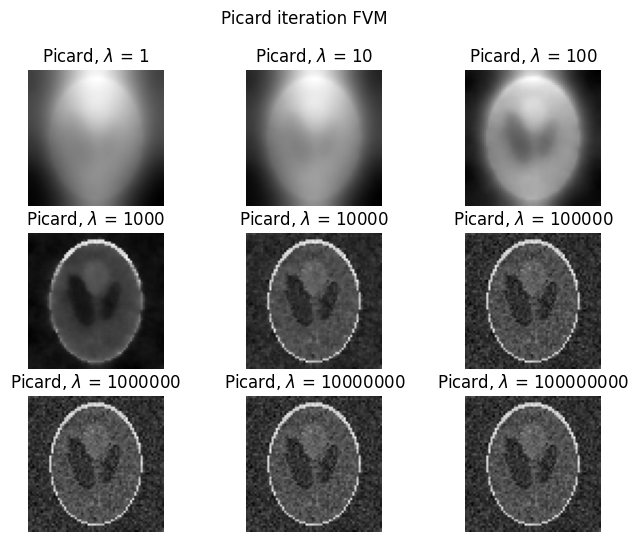

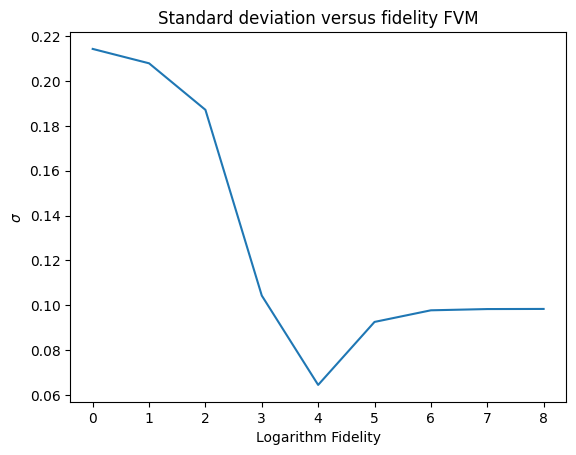

In [61]:
#Defining the parameters
#Note that since we are using a cell centered approach, the dx and dy are now 1/64
N_x = 64
N_y = 64
dx = 1/64
dy = 1/64
iter = 100
eps = 10**(-5)



method = 1
plt.figure(figsize=(8,6))
plt.suptitle('Picard iteration FVM')
sigma = np.zeros(9)
for i in range(9):
    fidelity = 10**(i)
    k, u_new = Picard_Iteration(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = fidelity,
                    phi0 = fn, c = c, begin_u = fn[::-1].flatten(), iter = iter, eps = eps, Type = "FVM")

    #We need to reshape it back to 64x64
    fs = u_new.reshape((64,64))[::-1]

    print("fidelity parameter", fidelity, "converged in", k, "Iteration(s)")

    plt.subplot(3, 3, i+1)
    plt.title(f'Picard, $\lambda$ = {fidelity}')
    plt.imshow(fs, extent=[0, 1, 0, 1], cmap = 'gray')
    plt.axis('square')
    plt.axis('off')

    if fm.size > 0:
        sigma[i] = np.linalg.norm(fs - fm, ord='fro') / np.sqrt(N_x*N_y)

if fm.size > 0:
    plt.figure()
    plt.title('Standard deviation versus fidelity FVM')
    plt.plot(range(9), sigma)
    plt.xlabel('Logarithm Fidelity')
    plt.ylabel('$\sigma$')

#### Solving for multiple lambdas using FDM with the nonlinear c

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\2435356240.py:24: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Picard, $\lambda$ = {fidelity}')
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\2435356240.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$')


fidelity parameter 1 converged in 2 Iteration(s)
fidelity parameter 10 converged in 3 Iteration(s)
fidelity parameter 100 converged in 7 Iteration(s)
fidelity parameter 1000 converged in 30 Iteration(s)
fidelity parameter 10000 converged in 7 Iteration(s)
fidelity parameter 100000 converged in 3 Iteration(s)
fidelity parameter 1000000 converged in 1 Iteration(s)
fidelity parameter 10000000 converged in 1 Iteration(s)
fidelity parameter 100000000 converged in 0 Iteration(s)


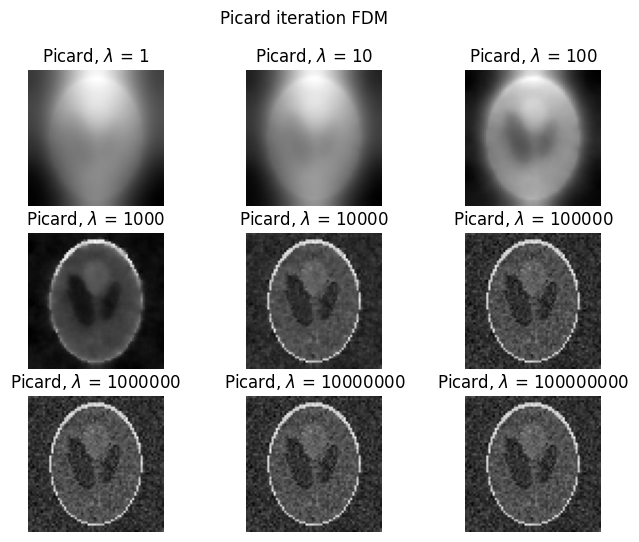

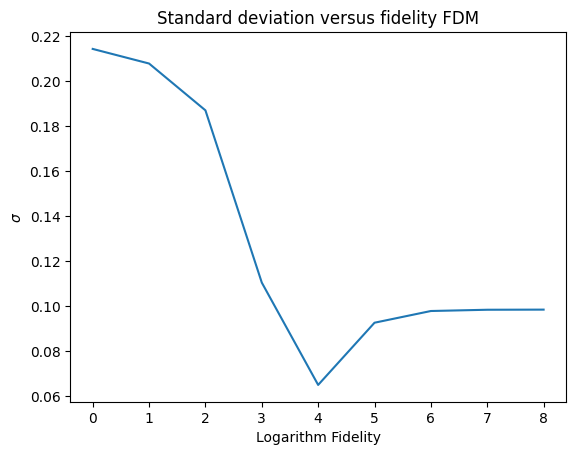

In [62]:
#Defining the parameters
N_x = 64
N_y = 64
dx = 1/63
dy = 1/63
iter = 100
eps = 10**(-5)

method = 1
plt.figure(figsize=(8,6))
plt.suptitle('Picard iteration FDM')
sigma = np.zeros(9)
for i in range(9):
    fidelity = 10**(i)
    k, u_new = Picard_Iteration(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = fidelity,
                    phi0 = fn, c = c, begin_u = fn[::-1].flatten(), iter = iter, eps = eps, Type = "FDM")

    #We need to reshape it back to 64x64
    fs = u_new.reshape((64,64))[::-1]
    
    print("fidelity parameter", fidelity, "converged in", k, "Iteration(s)")

    plt.subplot(3, 3, i+1)
    plt.title(f'Picard, $\lambda$ = {fidelity}')
    plt.imshow(fs, extent=[0, 1, 0, 1], cmap = 'gray')
    plt.axis('square')
    plt.axis('off')

    if fm.size > 0:
        sigma[i] = np.linalg.norm(fs - fm, ord='fro') / np.sqrt(N_x*N_y)

if fm.size > 0:
    plt.figure()
    plt.title('Standard deviation versus fidelity FDM')
    plt.plot(range(9), sigma)
    plt.xlabel('Logarithm Fidelity')
    plt.ylabel('$\sigma$')

#### Solving the equation using Explicit Euler with $\lambda = 10^4$ with nonlinear c

<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\3489138276.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum x/N$')
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\3489138276.py:68: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$')


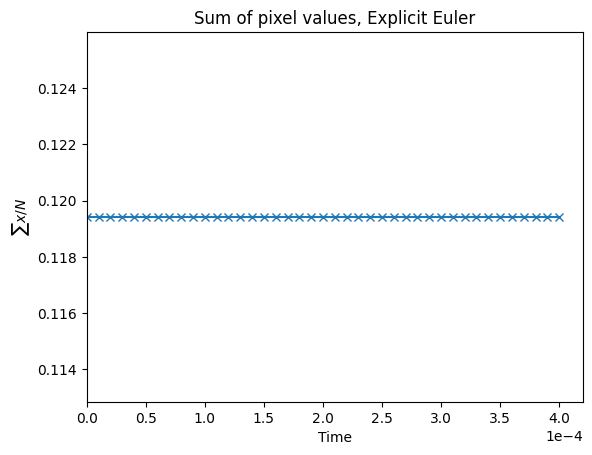

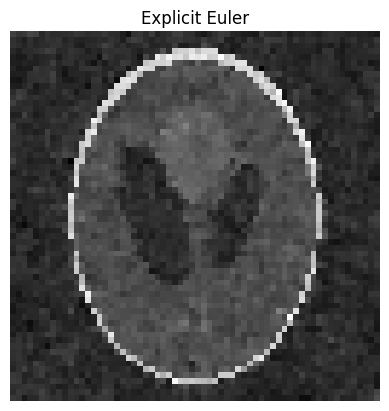

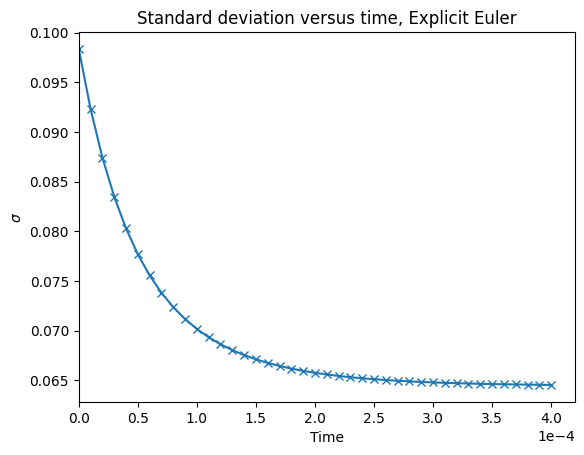

In [63]:
# Explicit Euler

#Defining the parameters
method = 2
fidelity = 10**(4)
dt = 10**(-5)
nt = 40
N_x = 64
N_y = 64
dx = 1/64
dy = 1/64
iter = 100
eps = 10**(-5)
Nonlinear_c = True

fs_old = copy.deepcopy(fn)
sum_x = np.ones(nt+1)
err_x = np.ones(nt+1)

#Initial values
sum_x[0] = np.sum(fs_old[::-1].flatten())/(N_x*N_y)
err_x[0] = np.linalg.norm(fs_old - fm, ord='fro') / np.sqrt(N_x*N_y)

#Defining the f vector
b = build_f_vector_FVM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = fidelity, phi0 = fs_old)

#Defining the initial condition
fs_old = copy.deepcopy(fs_old[::-1].flatten())

for i in range(1,nt+1):
    #Here we define Explicit Euler
    A = build_A_matrix_FVM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = fidelity, c = c, u = fs_old, nonlinear = Nonlinear_c)

    #We devide by dx*dy because of the M^{-1} matrix. We do -b, since b is now on the same side as the spacial
    fs_new = fs_old + dt*(A.toarray()@fs_old - b)/(dx*dy)

    #Calculating the values of sum and err
    sum_x[i] = np.sum(fs_new)/(N_x*N_y)
    err_x[i] = np.linalg.norm(fs_new.reshape((64,64))[::-1] - fm, ord='fro') / np.sqrt(N_x*N_y)

    fs_old = copy.deepcopy(fs_new)


# Plot the sum of the average pixel values:
t = np.arange(0, (len(sum_x))*dt, dt)
plt.figure()
plt.plot(t, sum_x, '-x')
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.title('Sum of pixel values, Explicit Euler')
plt.xlabel('Time')
plt.xlim(left=0)
plt.ylabel('$\sum x/N$')

plt.figure()
plt.title('Explicit Euler')
plt.imshow(fs_new.reshape((64,64))[::-1], extent=[0, 1, 0, 1], cmap = 'gray')
plt.axis('square')
plt.axis('off')

if fm.size > 0 :
    plt.figure()
    t = np.arange(0, (len(err_x))*dt, dt)
    plt.plot(t, err_x, '-x')
    plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    plt.title('Standard deviation versus time, Explicit Euler')
    plt.xlabel('Time')
    plt.xlim(left=0)
    plt.ylabel('$\sigma$')

#### Showing the total energy is constant using Explicit Euler

C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\747740670.py:1: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-x" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(t, abs(sum_x - sum_x[0]), '-x', linestyle = "None")


Text(0, 0.5, 'Precision')

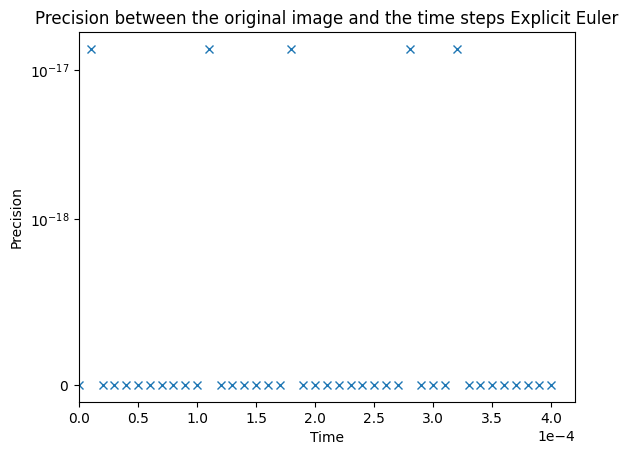

In [64]:
plt.plot(t, abs(sum_x - sum_x[0]), '-x', linestyle = "None")
plt.yscale('symlog',linthresh=1e-18)
plt.title('Precision between the original image and the time steps Explicit Euler')
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.xlabel('Time')
plt.xlim(left=0)
plt.ylabel('Precision')

#### Solving the equation using Implicit Euler with $\lambda = 10^4$ with nonlinear c

<>:52: SyntaxWarning: invalid escape sequence '\S'
<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\S'
<>:68: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\2388645288.py:52: SyntaxWarning: invalid escape sequence '\S'
  plt.ylabel('$\Sigma x/N$')
C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\2388645288.py:68: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$')


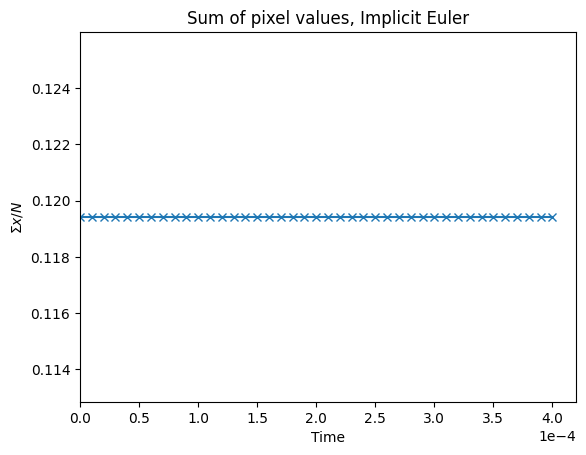

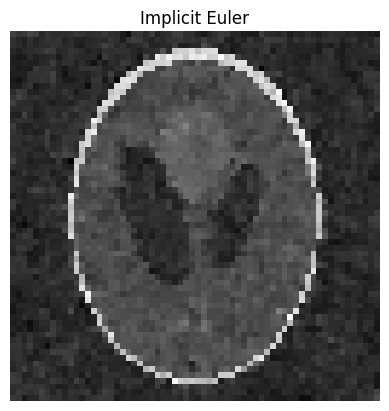

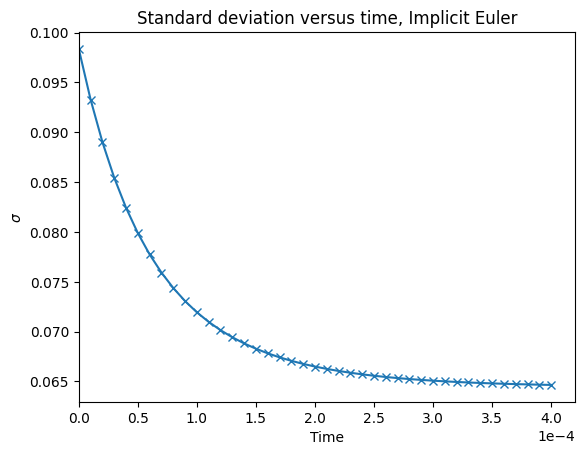

In [65]:
# Implicit Euler
method = 3
fidelity = 10**4
dt = 1e-5
nt = 40
N_x = 64
N_y = 64
dx = 1/64
dy = 1/64
iter = 100
eps = 1e-5
Nonlinear_c = True

fs_old = copy.deepcopy(fn)
sum_x = np.ones(nt+1)
err_x = np.ones(nt+1)

#Initial values
sum_x[0] = np.sum(fs_old.flatten())/(N_x*N_y)
err_x[0] = np.linalg.norm(fs_old - fm, ord='fro') / np.sqrt(N_x*N_y)

#Defining the f vector
b = build_f_vector_FVM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = fidelity, phi0 = fs_old)

#Defining the initial condition
fs_old = copy.deepcopy(fs_old[::-1].flatten())

for i in range(1,nt+1):
    #Here we define Implicit Euler
    A = build_A_matrix_FVM(N_x = N_x, N_y = N_y, dx = dx, dy = dy, Lambda = fidelity, c = c, u = fs_old, nonlinear = Nonlinear_c)

    #We devide by dx*dy for some terms because of the M^{-1} matrix. We do -b, since b is now on the same side as the spacial
    b_new = fs_old - dt*b/(dx*dy)
    A_new = lil_matrix(np.identity(N_x*N_y)) - dt*A/(dx*dy)
    fs_new = spsolve(A_new.tocsr(),b_new)

    #Calculating the values of sum and err
    sum_x[i] = np.sum(fs_new)/(N_x*N_y)
    err_x[i] = np.linalg.norm(fs_new.reshape((64,64))[::-1] - fm, ord='fro') / np.sqrt(N_x*N_y)

    fs_old = copy.deepcopy(fs_new)


# Plot the sum of the average pixel values:
t = np.arange(0, (len(sum_x))*dt, dt)
plt.figure()
plt.plot(t, sum_x, '-x')
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.title('Sum of pixel values, Implicit Euler')
plt.xlabel('Time')
plt.xlim(left=0)
plt.ylabel('$\Sigma x/N$')

plt.figure()
plt.title('Implicit Euler')
plt.imshow(fs_new.reshape((64,64))[::-1], extent=[0, 1, 0, 1], cmap = 'gray')
plt.axis('square')
plt.axis('off')

if fm.size > 0 :
    plt.figure()
    t = np.arange(0, (len(err_x))*dt, dt)
    plt.plot(t, err_x, '-x')
    plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    plt.title('Standard deviation versus time, Implicit Euler')
    plt.xlabel('Time')
    plt.xlim(left=0)
    plt.ylabel('$\sigma$')

plt.show()

#### Showing the total energy is constant using Implicit Euler

C:\Users\yordi\AppData\Local\Temp\ipykernel_3088\3079882102.py:1: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-x" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(t, abs(sum_x - sum_x[0]), '-x', linestyle = "None")


Text(0, 0.5, 'Precision')

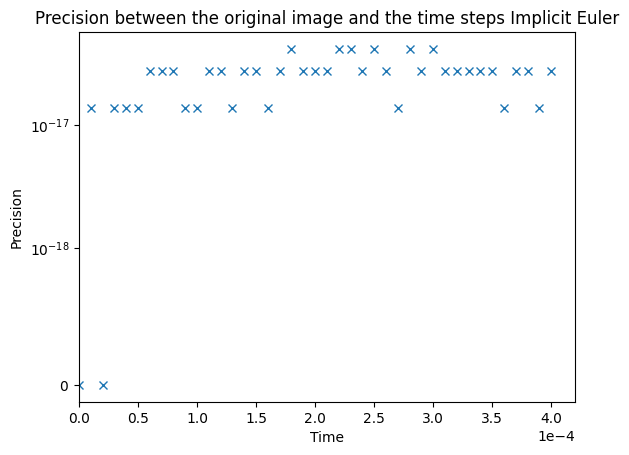

In [66]:
plt.plot(t, abs(sum_x - sum_x[0]), '-x', linestyle = "None")
plt.yscale('symlog',linthresh=1e-18)
plt.title('Precision between the original image and the time steps Implicit Euler')
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.xlabel('Time')
plt.xlim(left=0)
plt.ylabel('Precision')